
训练 co_imf1 模型...
最优参数: C=10, gamma=scale, epsilon=0.01
RMSE: 0.621021

训练 co_imf2 模型...
最优参数: C=100, gamma=0.01, epsilon=0.01
RMSE: 0.427489

训练 co_imf3 模型...
最优参数: C=100, gamma=0.01, epsilon=0.01
RMSE: 0.124806

=== 各Co-IMF最优参数汇总 ===
co_imf1: C=10, gamma=scale, epsilon=0.01
co_imf2: C=100, gamma=0.01, epsilon=0.01
co_imf3: C=100, gamma=0.01, epsilon=0.01

=== 最终预测性能指标 ===
RMSE: 0.789596
MAE: 0.586609
MAPE: 1.5444%
R²: 0.902907


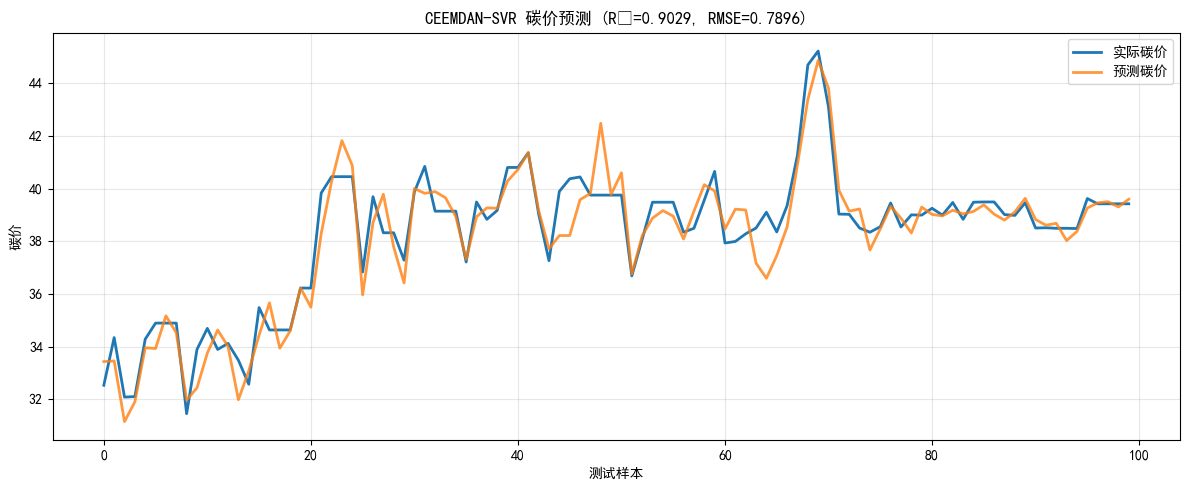


结果已保存至: test_predictions_ceemdan_svr.csv


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
TEST_SIZE = 100

np.random.seed(SEED)

# ==================== 读取数据 ====================
co_imf_df = pd.read_csv("ceemdan_se144_data.csv")
co_imf_df = co_imf_df[["co-imf0", "co-imf1", "co-imf2"]].copy()
co_imf_df.columns = ["co_imf1", "co_imf2", "co_imf3"]

price_df = pd.read_csv("guanzhoudemo_data.csv", names=["date", "close"], header=0)
price_df["date"] = pd.to_datetime(price_df["date"])
price_df = price_df.sort_values("date", ascending=True).reset_index(drop=True)
price_df["close"] = pd.to_numeric(price_df["close"], errors="coerce")

# 对齐长度
min_len = min(len(co_imf_df), len(price_df))
co_imf_df = co_imf_df.iloc[-min_len:].reset_index(drop=True)
price_df = price_df.iloc[-min_len:].reset_index(drop=True)

# ==================== 特征构造 ====================
def create_features(series, lags=[1, 2, 3, 5, 10]):
    df = pd.DataFrame({"target": series})
    for lag in lags:
        df[f"lag_{lag}"] = df["target"].shift(lag)
    df["ma_5"] = df["target"].shift(1).rolling(5).mean()
    df["ma_10"] = df["target"].shift(1).rolling(10).mean()
    return df.dropna()

# ==================== 划分 ====================
total_len = len(co_imf_df)
if total_len <= TEST_SIZE:
    raise ValueError(f"样本不足，总样本数={total_len}")

# ==================== 训练每个Co-IMF ====================
co_imf_names = ["co_imf1", "co_imf2", "co_imf3"]
predictions = {}
best_params_all = {}
feature_cols = ["lag_1", "lag_2", "lag_3", "lag_5", "lag_10", "ma_5", "ma_10"]

param_sets = [
    {"C": 1, "gamma": "scale", "epsilon": 0.01},
    {"C": 1, "gamma": "scale", "epsilon": 0.1},
    {"C": 10, "gamma": "scale", "epsilon": 0.01},
    {"C": 10, "gamma": "scale", "epsilon": 0.1},
    {"C": 100, "gamma": "scale", "epsilon": 0.01},
    {"C": 100, "gamma": "scale", "epsilon": 0.1},
    {"C": 100, "gamma": 0.01, "epsilon": 0.01},
    {"C": 100, "gamma": 0.1, "epsilon": 0.1},
    {"C": 50, "gamma": "scale", "epsilon": 0.05},
    {"C": 200, "gamma": "scale", "epsilon": 0.05},
]

for imf_name in co_imf_names:
    print(f"\n{'='*50}")
    print(f"训练 {imf_name} 模型...")
    
    imf_series = co_imf_df[imf_name].values
    feature_df = create_features(imf_series)
    
    X = feature_df[feature_cols].values
    y = feature_df["target"].values
    
    train_idx = len(X) - TEST_SIZE
    
    X_train, X_test = X[:train_idx], X[train_idx:]
    y_train, y_test = y[:train_idx], y[train_idx:]
    
    # 归一化
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    
    best_rmse = np.inf
    best_model = None
    best_params = None
    
    for params in param_sets:
        model = SVR(
            kernel='rbf',
            C=params["C"],
            gamma=params["gamma"],
            epsilon=params["epsilon"],
            cache_size=500
        )
        model.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = model.predict(X_test_scaled)
        y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_params = params
            best_scalers = (x_scaler, y_scaler)
    
    # 用最优模型和scaler预测
    x_scaler_best, y_scaler_best = best_scalers
    X_test_scaled_best = x_scaler_best.transform(X_test)
    y_pred_scaled_best = best_model.predict(X_test_scaled_best)
    predictions[imf_name] = y_scaler_best.inverse_transform(y_pred_scaled_best.reshape(-1, 1)).ravel()
    best_params_all[imf_name] = best_params
    
    print(f"最优参数: C={best_params['C']}, gamma={best_params['gamma']}, epsilon={best_params['epsilon']}")
    print(f"RMSE: {best_rmse:.6f}")

# ==================== 重构碳价 ====================
min_pred_len = min(len(predictions[name]) for name in co_imf_names)
for name in co_imf_names:
    predictions[name] = predictions[name][-min_pred_len:]

y_pred_final = predictions["co_imf1"] + predictions["co_imf2"] + predictions["co_imf3"]
y_test_true = price_df["close"].values[-min_pred_len:]

# ==================== 评估指标 ====================
rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_final))
mae = mean_absolute_error(y_test_true, y_pred_final)
mape = mean_absolute_percentage_error(y_test_true, y_pred_final) * 100
r2 = r2_score(y_test_true, y_pred_final)

print(f"\n{'='*50}")
print("=== 各Co-IMF最优参数汇总 ===")
for name in co_imf_names:
    p = best_params_all[name]
    print(f"{name}: C={p['C']}, gamma={p['gamma']}, epsilon={p['epsilon']}")

print(f"\n=== 最终预测性能指标 ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r2:.6f}")

# ==================== 绘图 ====================
plt.figure(figsize=(12, 5))
plt.plot(y_test_true, label="实际碳价", linewidth=2)
plt.plot(y_pred_final, label="预测碳价", linewidth=2, alpha=0.8)
plt.title(f"CEEMDAN-SVR 碳价预测 (R²={r2:.4f}, RMSE={rmse:.4f})")
plt.xlabel("测试样本")
plt.ylabel("碳价")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 保存 ====================
errors = y_pred_final - y_test_true
result_df = pd.DataFrame({
    "actual_close": y_test_true,
    "predicted_close": y_pred_final,
    "error": errors,
    "abs_error": np.abs(errors)
})
result_df.to_csv("test_predictions_ceemdan_svr.csv", index=False)
print("\n结果已保存至: test_predictions_ceemdan_svr.csv")